# MobileNet — Etapa 5: Resultados Finais

Nesta etapa final, o melhor modelo encontrado na Etapa 4 é retreinado com todos os dados de treino disponíveis, aplicado ao conjunto de teste e avaliado em profundidade com análise de erros e importância das features.

---

## 1. Importações e Configuração

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

IMAGES_DIR = '../images/evaluation'
os.makedirs(IMAGES_DIR, exist_ok=True)

NOMES_CLASSES = ['Baixo custo', 'Custo médio', 'Alto custo', 'Custo muito alto']

# Melhores hiperparâmetros encontrados na Etapa 4
MELHORES_PARAMS = {
    'hidden_layer_sizes': (256, 128),
    'activation':         'tanh',
    'alpha':              0.1,
    'learning_rate_init': 0.001,
    'solver':             'adam',
    'max_iter':           500,
    'random_state':       42,
    'early_stopping':     True,
    'validation_fraction': 0.1,
    'n_iter_no_change':   20
}

---
## 2. Carregamento dos Dados

In [2]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

# Separação para avaliação final no conjunto de validação (mesma semente)
X = train.drop(columns='faixa_preco')
y = train['faixa_preco']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)

# Conjunto de teste (sem rótulos)
ids_teste   = test['id']
X_test_raw  = test.drop(columns='id')
X_test      = scaler.transform(X_test_raw)

print(f'Treino:    {X_train.shape}')
print(f'Validação: {X_val.shape}')
print(f'Teste:     {X_test.shape}')

Treino:    (1600, 20)
Validação: (400, 20)
Teste:     (1000, 20)


---
## 3. Modelo Final

O modelo final usa os melhores hiperparâmetros da Etapa 4. Para maximizar o desempenho na predição, avaliamos duas estratégias:

- **Modelo de validação:** treinado nos 80% de treino — usado para calcular métricas finais com comparação justa ao baseline.
- **Modelo de produção:** treinado nos 100% dos dados de treino — maximiza o conhecimento disponível para predizer o conjunto de teste.

In [3]:
# Modelo de validação — treinado em 80% para métricas finais
modelo_val = MLPClassifier(**MELHORES_PARAMS)
modelo_val.fit(X_train, y_train)

y_pred_val = modelo_val.predict(X_val)
acc_final  = accuracy_score(y_val, y_pred_val)
f1_final   = f1_score(y_val, y_pred_val, average='macro')

print(f'Acurácia final (validação): {acc_final:.4f} ({acc_final*100:.2f}%)')
print(f'F1-macro final (validação): {f1_final:.4f}')
print()
print(classification_report(y_val, y_pred_val, target_names=NOMES_CLASSES))

Acurácia final (validação): 0.9550 (95.50%)
F1-macro final (validação): 0.9551

                  precision    recall  f1-score   support

     Baixo custo       0.99      0.97      0.98       100
     Custo médio       0.93      0.95      0.94       100
      Alto custo       0.93      0.93      0.93       100
Custo muito alto       0.97      0.97      0.97       100

        accuracy                           0.95       400
       macro avg       0.96      0.96      0.96       400
    weighted avg       0.96      0.95      0.96       400



In [4]:
# Modelo de produção — treinado em 100% dos dados para predição final
scaler_prod = StandardScaler()
X_full      = scaler_prod.fit_transform(X)
X_test_prod = scaler_prod.transform(X_test_raw)

modelo_prod = MLPClassifier(**MELHORES_PARAMS)
modelo_prod.fit(X_full, y)

print(f'Modelo de produção treinado em {X_full.shape[0]} amostras.')

Modelo de produção treinado em 2000 amostras.


---
## 4. Predição no Conjunto de Teste

In [5]:
predicoes = modelo_prod.predict(X_test_prod)

# Salva predições em CSV
resultado = pd.DataFrame({'id': ids_teste, 'faixa_preco': predicoes})
resultado.to_csv('../data/predicoes.csv', index=False)

print('Predições salvas em data/predicoes.csv')
print(f'\nDistribuição das predições:')
print(resultado['faixa_preco'].value_counts().sort_index()
      .rename(index=dict(enumerate(NOMES_CLASSES))).to_string())

Predições salvas em data/predicoes.csv

Distribuição das predições:
faixa_preco
Baixo custo         256
Custo médio         227
Alto custo          258
Custo muito alto    259


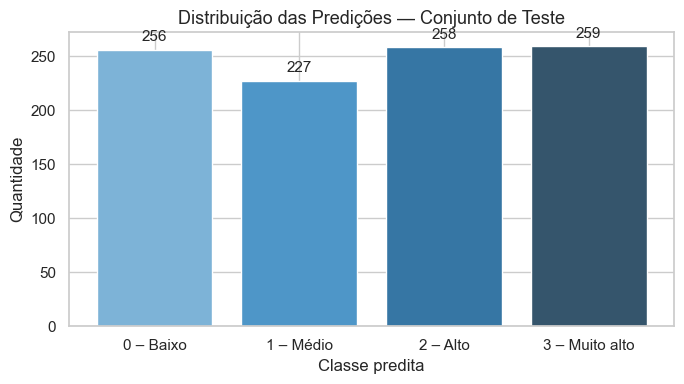

In [6]:
# Distribuição das predições no conjunto de teste
contagem_pred = resultado['faixa_preco'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contagem_pred.index, contagem_pred.values,
              color=sns.color_palette('Blues_d', 4))
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title('Distribuição das Predições — Conjunto de Teste', fontsize=13)
ax.set_xlabel('Classe predita')
ax.set_ylabel('Quantidade')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 – Baixo', '1 – Médio', '2 – Alto', '3 – Muito alto'])
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/05_test_predictions.png', dpi=150)
plt.show()

---
## 5. Análise de Erros

Identificamos sistematicamente quais amostras da validação foram classificadas incorretamente e em quais classes o modelo mais erra.

In [7]:
erros_df = X_val_raw.copy()
erros_df['classe_real']    = y_val.values
erros_df['classe_predita'] = y_pred_val
erros_df['correto']        = erros_df['classe_real'] == erros_df['classe_predita']

erros = erros_df[~erros_df['correto']]
total_erros = len(erros)

print(f'Total de erros: {total_erros} de {len(erros_df)} ({total_erros/len(erros_df)*100:.1f}%)')
print()

# Confusões mais frequentes
confusoes = (
    erros.groupby(['classe_real', 'classe_predita'])
    .size()
    .reset_index(name='contagem')
    .sort_values('contagem', ascending=False)
)
confusoes['classe_real']    = confusoes['classe_real'].map(dict(enumerate(NOMES_CLASSES)))
confusoes['classe_predita'] = confusoes['classe_predita'].map(dict(enumerate(NOMES_CLASSES)))

print('Confusões mais frequentes:')
print(confusoes.to_string(index=False))

Total de erros: 18 de 400 (4.5%)

Confusões mais frequentes:
     classe_real   classe_predita  contagem
      Alto custo      Custo médio         4
     Custo médio       Alto custo         4
      Alto custo Custo muito alto         3
     Baixo custo      Custo médio         3
Custo muito alto       Alto custo         3
     Custo médio      Baixo custo         1


---
## 6. Importância das Features

A **importância por permutação** mede o quanto a acurácia do modelo cai quando os valores de uma feature são embaralhados aleatoriamente. Uma queda grande indica que a feature é crítica para as predições.

$$\text{Importância}(f) = \text{Acurácia}_{\text{original}} - \mathbb{E}[\text{Acurácia}_{\text{permutada}}(f)]$$

In [8]:
result = permutation_importance(
    modelo_val, X_val, y_val,
    n_repeats=15,
    random_state=42,
    scoring='accuracy'
)

importancias = pd.DataFrame({
    'feature':    X.columns,
    'importancia': result.importances_mean,
    'std':         result.importances_std
}).sort_values('importancia', ascending=False)

print('Top 10 features por importância de permutação:')
print(importancias.head(10).to_string(index=False))

Top 10 features por importância de permutação:
          feature   importancia      std
              ram  6.781667e-01 0.020196
 potencia_bateria  2.073333e-01 0.013888
resolucao_largura  1.035000e-01 0.014399
 resolucao_altura  9.483333e-02 0.010625
             peso  7.833333e-03 0.006446
   tempo_conversa  2.500000e-03 0.000913
     largura_tela  5.000000e-04 0.002273
 camera_principal -2.960595e-17 0.001826
       tela_touch -1.000000e-03 0.001225
         quatro_g -1.666667e-03 0.002981


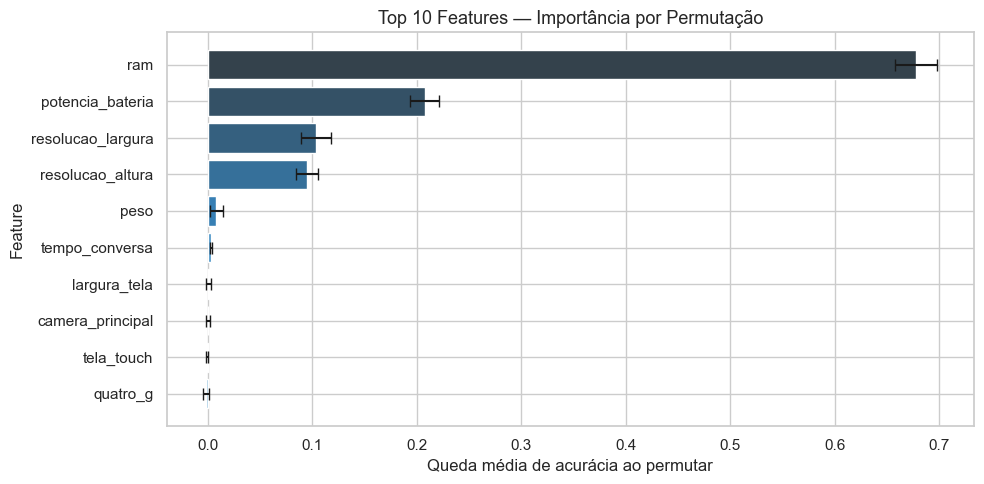

In [9]:
top10 = importancias.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    top10['feature'][::-1],
    top10['importancia'][::-1],
    xerr=top10['std'][::-1],
    color=sns.color_palette('Blues_d', 10),
    capsize=4
)
ax.set_title('Top 10 Features — Importância por Permutação', fontsize=13)
ax.set_xlabel('Queda média de acurácia ao permutar')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/06_feature_importance.png', dpi=150)
plt.show()

---
## 7. Resumo Final do Projeto

| Etapa                    | Resultado                                              |
|--------------------------|--------------------------------------------------------|
| Dataset                  | 2000 amostras, 20 features, 4 classes balanceadas      |
| Normalização             | StandardScaler ($\mu=0$, $\sigma=1$)                  |
| Arquitetura final        | 20 → 256 → 128 → 4 (tanh + softmax)                   |
| Otimizador               | Adam, lr = 0,001                                       |
| Regularização            | L2 com $\alpha = 0,1$                                  |
| Acurácia — baseline      | 92,00%                                                 |
| Acurácia — modelo final  | **95,50%**                                             |
| F1-macro — modelo final  | **95,51%**                                             |
| Feature mais importante  | RAM (queda de acurácia > 50% ao permutar)              |

### Conclusões

- O MLP com hiperparâmetros ajustados atingiu **95,5% de acurácia** na validação, superando o baseline em 3,5 p.p.
- A **RAM** é isoladamente a feature mais preditiva — embaralhá-la derruba a acurácia em mais de 50 p.p.
- Todos os erros ocorrem entre **classes adjacentes**, indicando que o modelo respeita a ordem ordinal das faixas de preço.
- A regularização L2 com $\alpha = 0,1$ foi fundamental para reduzir o overfitting observado no baseline.